# Regressão Linear - SOJA3 (Dataset Janelas Deslizantes)
## Análise comparativa de modelos de Machine Learning - Agro Brasil - TCC

Este notebook implementa modelos de regressão linear para prever o preço de fechamento futuro das ações SOJA3 em diferentes horizontes temporais (3, 7, 15 e 30 dias).

**Dataset utilizado:** Dataset com janelas deslizantes (lag features de 2, 4 e 6 dias para Open, High, Low e Close).

### Importação das bibliotecas e carregamento do dataset

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from scipy import stats
import os

# Configuração para salvar gráficos
OUTPUT_DIR = './'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Carrega o dataset tratado com janelas deslizantes
df = pd.read_csv('../../../../datasets/datasets_janelas/regressao/SOJA3_tratado.csv', index_col=0, parse_dates=True)

print("="*60)
print("DATASET SOJA3 - REGRESSÃO LINEAR (JANELAS DESLIZANTES)")
print("="*60)
print(f"\nPrimeiras 5 linhas do DataFrame:")
print(df.head())

print(f"\nInformações gerais do DataFrame:")
print(df.info())

print(f"\nColunas disponíveis:")
print(df.columns.tolist())

print(f"\nEstatísticas descritivas:")
print(df.describe())

DATASET SOJA3 - REGRESSÃO LINEAR (JANELAS DESLIZANTES)

Primeiras 5 linhas do DataFrame:
                Close       High        Low       Open   Volume  Close_3d_fut  \
Date                                                                            
2021-05-10  13.665610  13.982154  13.665610  13.837448   601800     14.633327   
2021-05-11  13.566125  13.701786  13.340023  13.566125   383600     15.103620   
2021-05-12  13.611345  13.927888  13.430464  13.475684   531400     15.266415   
2021-05-13  14.633327  15.212148  13.611346  13.837448  3053300     15.121708   
2021-05-14  15.103620  15.501558  14.741855  14.814207  2071600     14.723768   

            Close_7d_fut  Close_15d_fut  Close_30d_fut  Open_lag2d  ...  \
Date                                                                ...   
2021-05-10     14.723768      14.063551      13.538994   14.334873  ...   
2021-05-11     14.289653      14.470534      13.222449   13.882669  ...   
2021-05-12     14.434359      14.144947    

### Preparação dos dados para modelagem

In [2]:
# Identificar colunas de lag (janelas deslizantes)
lag_cols = [col for col in df.columns if '_lag' in col]
print(f"Colunas de lag encontradas ({len(lag_cols)}): {lag_cols}")

# Definir variáveis independentes (features base + lag)
base_features = ['Close', 'Low', 'High', 'Open']
X = df[base_features + lag_cols]

# Definir targets (variáveis dependentes) - janelas temporais
targets = {
    '3d': df['Close_3d_fut'],
    '7d': df['Close_7d_fut'], 
    '15d': df['Close_15d_fut'],
    '30d': df['Close_30d_fut']
}

print("\nVariáveis independentes (X):")
print(X.columns.tolist())
print(f"\nShape de X: {X.shape}")

print("\nTargets (janelas temporais):")
for name, target in targets.items():
    print(f"  - {name}: {target.name}")

Colunas de lag encontradas (12): ['Open_lag2d', 'Open_lag4d', 'Open_lag6d', 'High_lag2d', 'High_lag4d', 'High_lag6d', 'Low_lag2d', 'Low_lag4d', 'Low_lag6d', 'Close_lag2d', 'Close_lag4d', 'Close_lag6d']

Variáveis independentes (X):
['Close', 'Low', 'High', 'Open', 'Open_lag2d', 'Open_lag4d', 'Open_lag6d', 'High_lag2d', 'High_lag4d', 'High_lag6d', 'Low_lag2d', 'Low_lag4d', 'Low_lag6d', 'Close_lag2d', 'Close_lag4d', 'Close_lag6d']

Shape de X: (881, 16)

Targets (janelas temporais):
  - 3d: Close_3d_fut
  - 7d: Close_7d_fut
  - 15d: Close_15d_fut
  - 30d: Close_30d_fut


### Treinamento dos Modelos de Regressão Linear

In [3]:
print("MODELOS DE REGRESSÃO LINEAR - SOJA3 (JANELAS DESLIZANTES)")
print("="*60)

# Dicionário para armazenar modelos treinados e métricas
models = {}

# Treinar modelo para cada janela temporal
for period, y in targets.items():
    # Divisão treino-teste (80/20)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)
    
    # Treinar modelo
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Fazer predições
    y_pred = model.predict(X_test)
    
    # Calcular métricas
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    
    # Armazenar modelo e métricas
    models[period] = {
        'model': model,
        'r2': r2,
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_pred': y_pred
    }
    
    print(f"\nMODELO {period.upper()} - Predição Close {period} futuro:")
    print(f"  R²: {r2:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  Intercepto: {model.intercept_:.4f}")
    print(f"  Coeficientes (primeiros 8):")
    for i, feature in enumerate(X.columns[:8]):
        print(f"    {feature}: {model.coef_[i]:.4f}")
    if len(X.columns) > 8:
        print(f"    ... e mais {len(X.columns) - 8} coeficientes")

print(f"\n" + "="*60)
print(f"✓ 4 modelos treinados com sucesso!")
print("="*60)

MODELOS DE REGRESSÃO LINEAR - SOJA3 (JANELAS DESLIZANTES)

MODELO 3D - Predição Close 3d futuro:
  R²: 0.9392
  MAE: 0.3518
  RMSE: 0.4870
  Intercepto: 0.4168
  Coeficientes (primeiros 8):
    Close: 0.6837
    Low: -0.0245
    High: 0.3806
    Open: -0.1781
    Open_lag2d: -0.1575
    Open_lag4d: -0.1187
    Open_lag6d: 0.0536
    High_lag2d: 0.0738
    ... e mais 8 coeficientes

MODELO 7D - Predição Close 7d futuro:
  R²: 0.8873
  MAE: 0.4807
  RMSE: 0.6502
  Intercepto: 0.8221
  Coeficientes (primeiros 8):
    Close: 0.8201
    Low: -0.0842
    High: 0.2104
    Open: -0.1388
    Open_lag2d: -0.1203
    Open_lag4d: -0.0725
    Open_lag6d: -0.0422
    High_lag2d: 0.0418
    ... e mais 8 coeficientes

MODELO 15D - Predição Close 15d futuro:
  R²: 0.7533
  MAE: 0.7256
  RMSE: 0.9695
  Intercepto: 1.7092
  Coeficientes (primeiros 8):
    Close: 0.7229
    Low: -0.0573
    High: 0.3964
    Open: -0.3097
    Open_lag2d: -0.2108
    Open_lag4d: -0.1397
    Open_lag6d: -0.0766
    High_lag2

### Tabela Resumo das Métricas

In [4]:
# Criar DataFrame com resumo das métricas
metrics_summary = pd.DataFrame({
    'Horizonte': ['3 dias', '7 dias', '15 dias', '30 dias'],
    'R²': [models['3d']['r2'], models['7d']['r2'], models['15d']['r2'], models['30d']['r2']],
    'MAE': [models['3d']['mae'], models['7d']['mae'], models['15d']['mae'], models['30d']['mae']],
    'RMSE': [models['3d']['rmse'], models['7d']['rmse'], models['15d']['rmse'], models['30d']['rmse']]
})

print("\nRESUMO DAS MÉTRICAS - SOJA3 (JANELAS DESLIZANTES)")
print("="*60)
print(metrics_summary.to_string(index=False))

# Salvar métricas em CSV
metrics_summary.to_csv(f'{OUTPUT_DIR}metricas_soja3_janelas.csv', index=False)
print(f"\n✓ Métricas salvas em metricas_soja3_janelas.csv")


RESUMO DAS MÉTRICAS - SOJA3 (JANELAS DESLIZANTES)
Horizonte       R²      MAE     RMSE
   3 dias 0.939191 0.351779 0.487027
   7 dias 0.887262 0.480671 0.650219
  15 dias 0.753339 0.725563 0.969512
  30 dias 0.543130 1.113979 1.399694

✓ Métricas salvas em metricas_soja3_janelas.csv


---
# Análises Gráficas

### Gráficos de Série Temporal - Real vs Predito

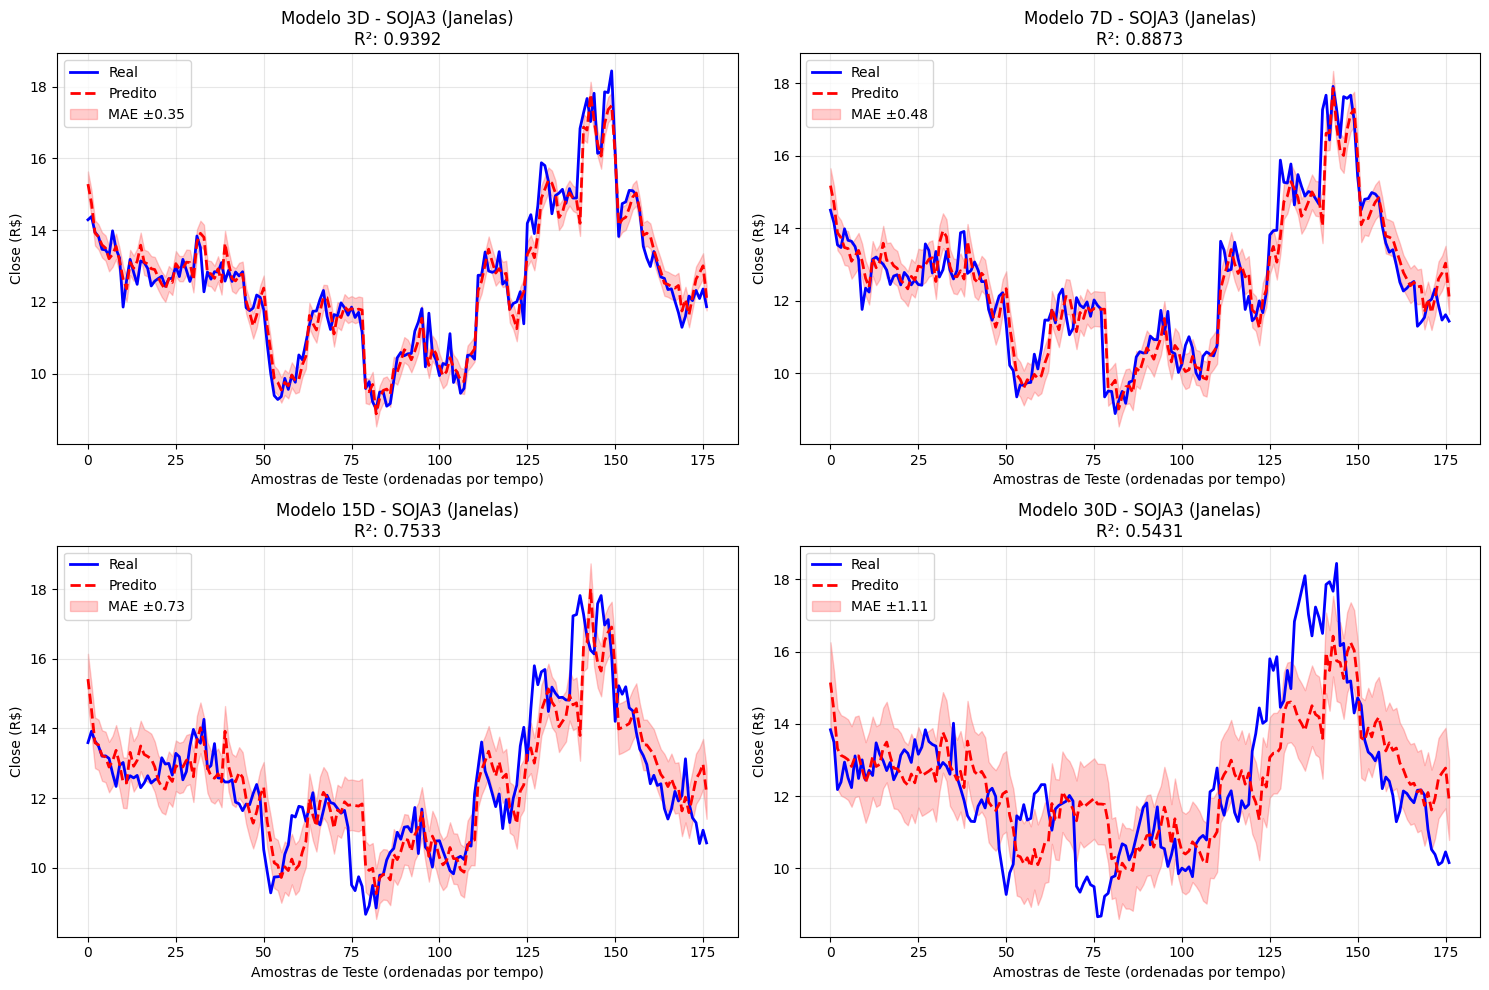

✓ Gráfico de série temporal salvo


In [5]:
# Gráficos de série temporal
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']
    mae = model_data['mae']
    
    # Ordenar por índice para visualização temporal
    test_indices = model_data['X_test'].index
    sorted_indices = sorted(range(len(test_indices)), key=lambda i: test_indices[i])
    
    y_test_sorted = y_test.iloc[sorted_indices]
    y_pred_sorted = y_pred[sorted_indices]
    
    # Plotar
    ax = axes[idx]
    ax.plot(range(len(y_test_sorted)), y_test_sorted, 'b-', label='Real', linewidth=2)
    ax.plot(range(len(y_pred_sorted)), y_pred_sorted, 'r--', label='Predito', linewidth=2)
    
    # Adicionar túnel do MAE
    ax.fill_between(range(len(y_pred_sorted)), 
                    y_pred_sorted - mae, 
                    y_pred_sorted + mae, 
                    alpha=0.2, color='red', label=f'MAE ±{mae:.2f}')
    
    ax.set_title(f'Modelo {period.upper()} - SOJA3 (Janelas)\nR²: {model_data["r2"]:.4f}')
    ax.set_xlabel('Amostras de Teste (ordenadas por tempo)')
    ax.set_ylabel('Close (R$)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}serie_temporal_soja3_janelas.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráfico de série temporal salvo")

### Gráficos de Resíduos

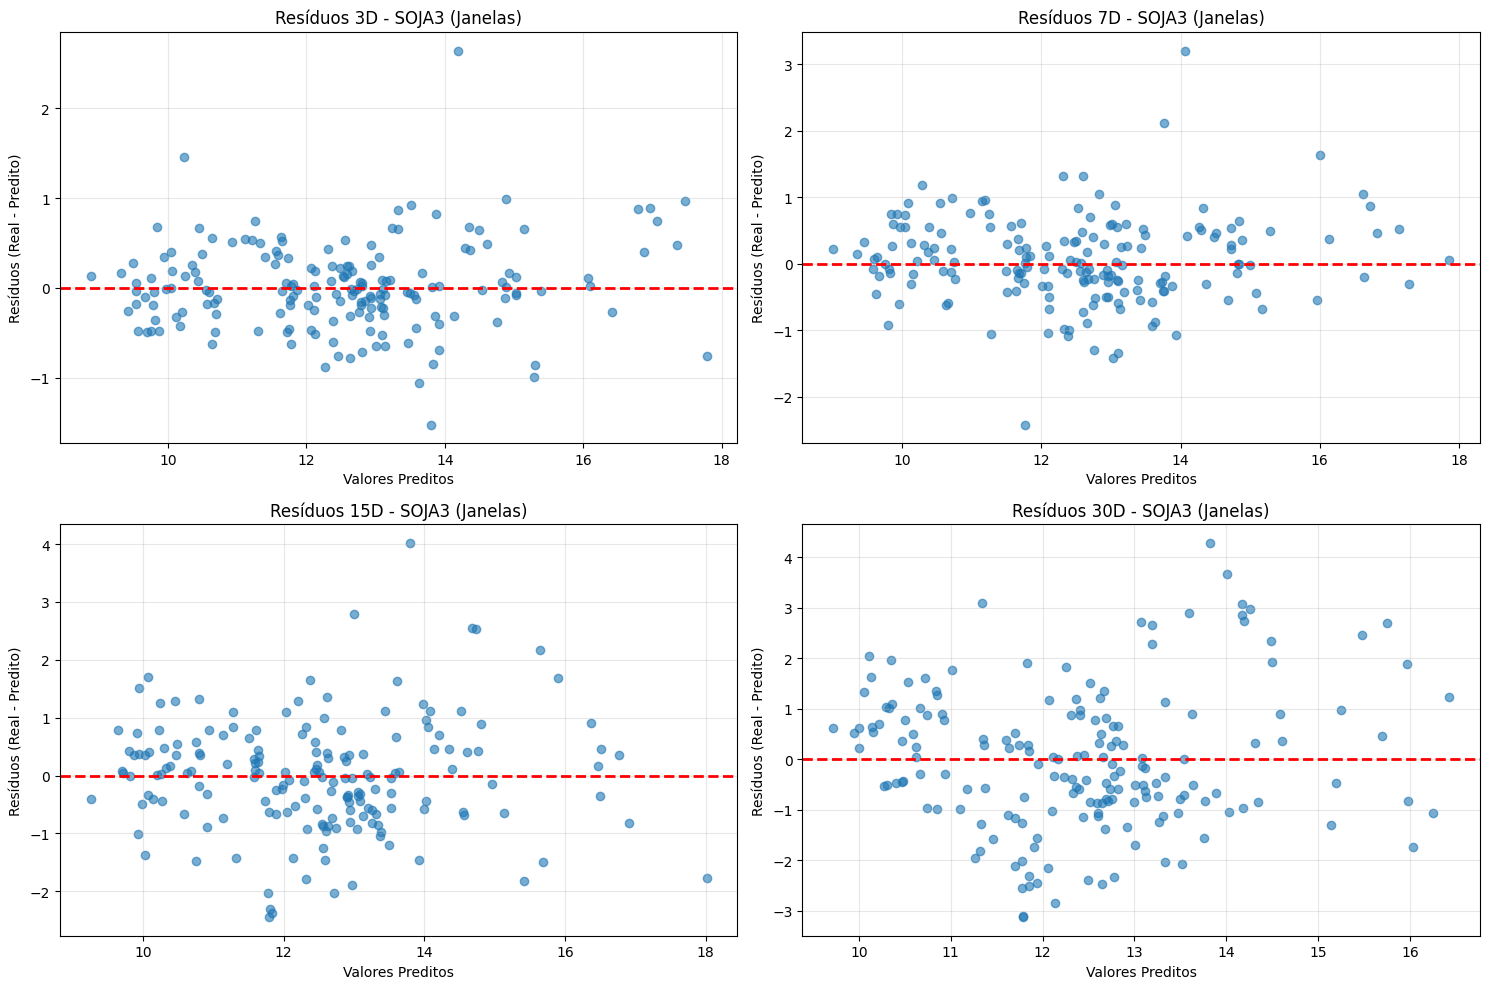

✓ Gráfico de resíduos salvo


In [6]:
# Gráficos de resíduos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']
    residuos = y_test - y_pred
    
    # Plotar
    ax = axes[idx]
    ax.scatter(y_pred, residuos, alpha=0.6)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'Resíduos {period.upper()} - SOJA3 (Janelas)')
    ax.set_xlabel('Valores Preditos')
    ax.set_ylabel('Resíduos (Real - Predito)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}residuos_soja3_janelas.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráfico de resíduos salvo")

### Gráficos Real vs Predito

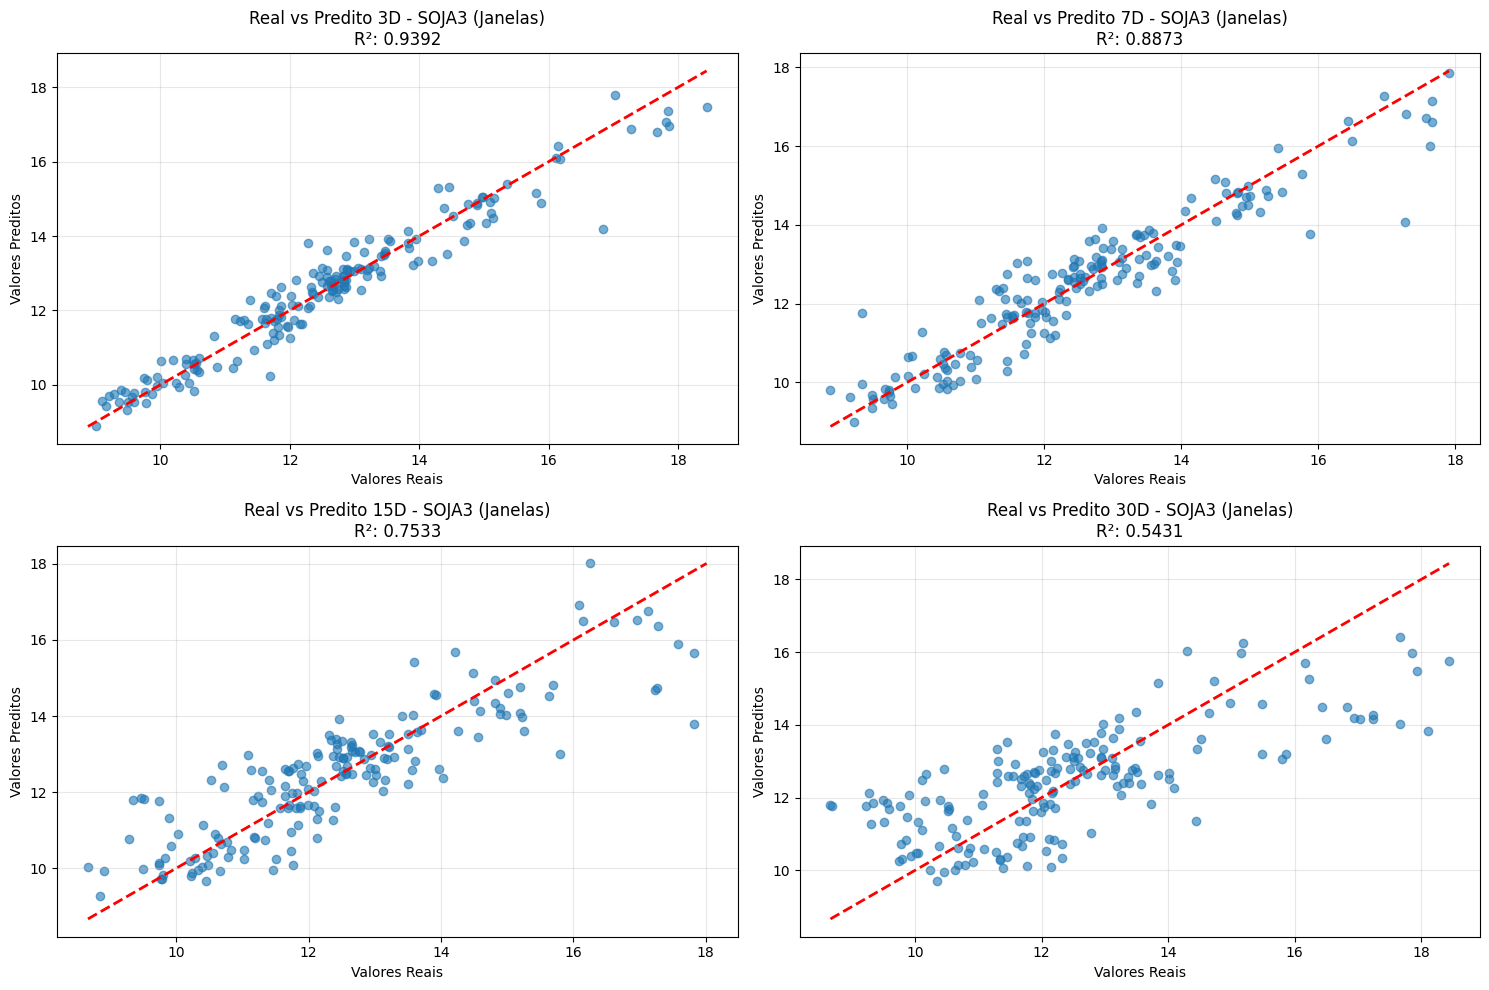

✓ Gráfico real vs predito salvo


In [7]:
# Gráficos Real vs Predito
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']
    
    # Plotar
    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.6)
    
    # Linha diagonal y=x (predição perfeita)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    
    ax.set_title(f'Real vs Predito {period.upper()} - SOJA3 (Janelas)\nR²: {model_data["r2"]:.4f}')
    ax.set_xlabel('Valores Reais')
    ax.set_ylabel('Valores Preditos')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}real_vs_predito_soja3_janelas.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráfico real vs predito salvo")

### Comparação das Métricas (R² e MAE)

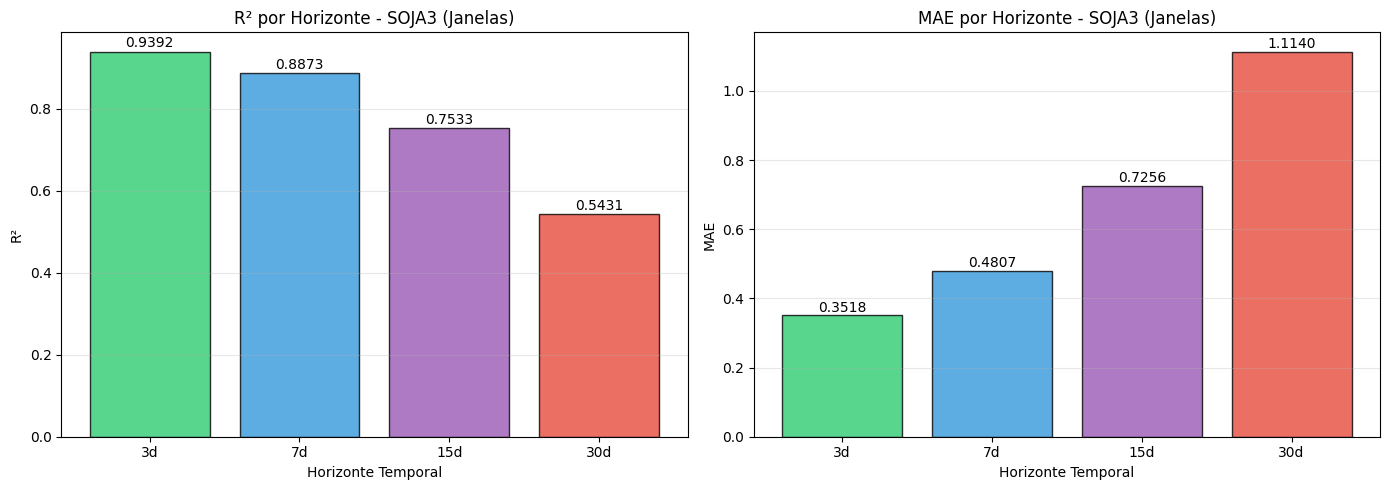

✓ Gráfico de comparação de métricas salvo


In [8]:
# Comparação das métricas entre horizontes
periods = ['3d', '7d', '15d', '30d']
r2_values = [models[p]['r2'] for p in periods]
mae_values = [models[p]['mae'] for p in periods]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico R²
x = np.arange(len(periods))
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']

ax1.bar(x, r2_values, color=colors, alpha=0.8, edgecolor='black')
ax1.set_xlabel('Horizonte Temporal')
ax1.set_ylabel('R²')
ax1.set_title('R² por Horizonte - SOJA3 (Janelas)')
ax1.set_xticks(x)
ax1.set_xticklabels(periods)
ax1.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for i, v in enumerate(r2_values):
    ax1.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

# Gráfico MAE
ax2.bar(x, mae_values, color=colors, alpha=0.8, edgecolor='black')
ax2.set_xlabel('Horizonte Temporal')
ax2.set_ylabel('MAE')
ax2.set_title('MAE por Horizonte - SOJA3 (Janelas)')
ax2.set_xticks(x)
ax2.set_xticklabels(periods)
ax2.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for i, v in enumerate(mae_values):
    ax2.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}comparacao_metricas_soja3_janelas.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráfico de comparação de métricas salvo")

### Histogramas dos Resíduos

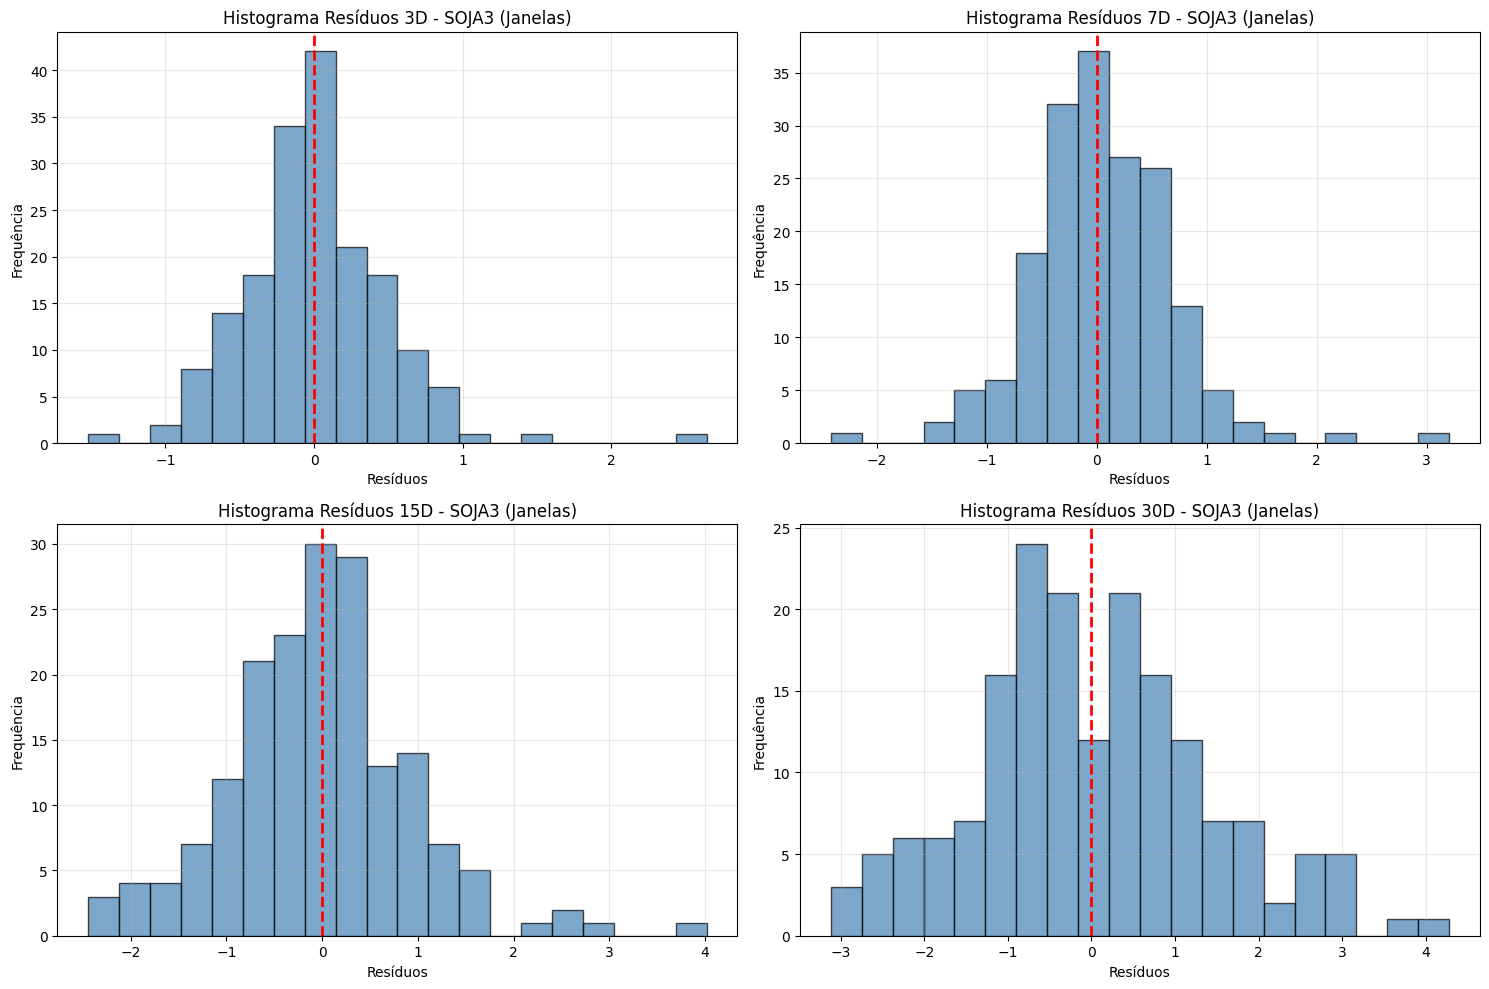

✓ Histograma de resíduos salvo


In [9]:
# Histogramas dos resíduos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']
    residuos = y_test - y_pred
    
    # Plotar
    ax = axes[idx]
    ax.hist(residuos, bins=20, alpha=0.7, edgecolor='black', color='steelblue')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'Histograma Resíduos {period.upper()} - SOJA3 (Janelas)')
    ax.set_xlabel('Resíduos')
    ax.set_ylabel('Frequência')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}histograma_residuos_soja3_janelas.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Histograma de resíduos salvo")

### Resíduos vs Ordem Temporal

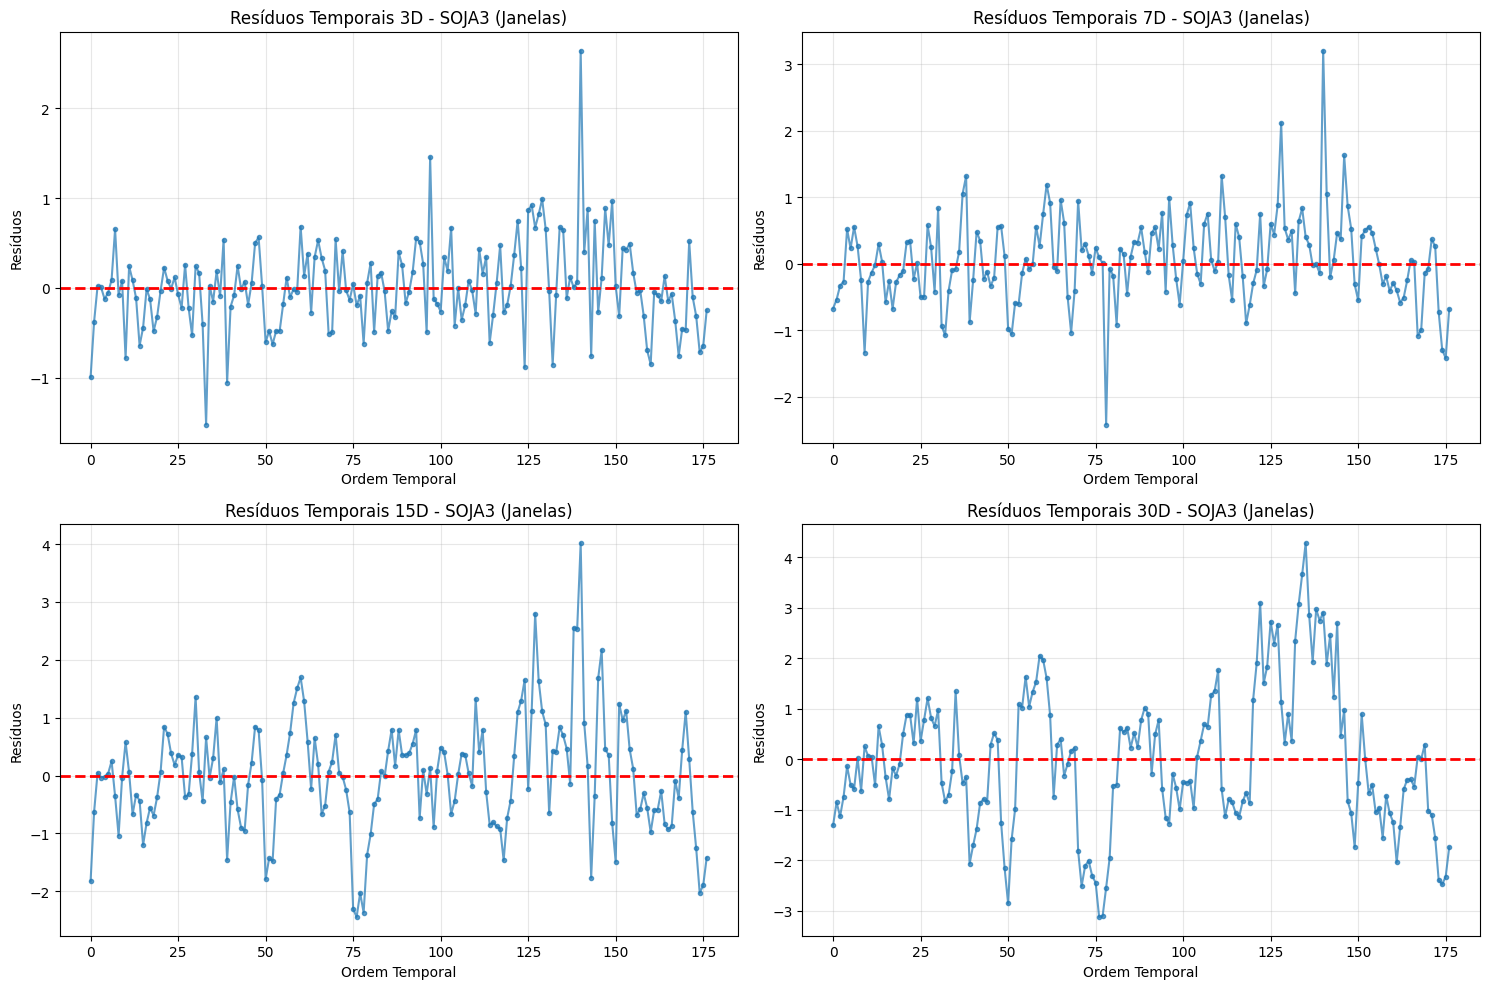

✓ Gráfico de resíduos temporais salvo


In [10]:
# Resíduos vs Ordem Temporal
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']
    residuos = y_test - y_pred
    
    # Ordenar por índice temporal
    test_indices = model_data['X_test'].index
    sorted_indices = sorted(range(len(test_indices)), key=lambda i: test_indices[i])
    residuos_sorted = residuos.iloc[sorted_indices]
    
    # Plotar
    ax = axes[idx]
    ax.plot(range(len(residuos_sorted)), residuos_sorted, 'o-', markersize=3, alpha=0.7)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'Resíduos Temporais {period.upper()} - SOJA3 (Janelas)')
    ax.set_xlabel('Ordem Temporal')
    ax.set_ylabel('Resíduos')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}residuos_temporais_soja3_janelas.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráfico de resíduos temporais salvo")

### Gráfico de Dispersão com Intervalo de Confiança (IC 95%)

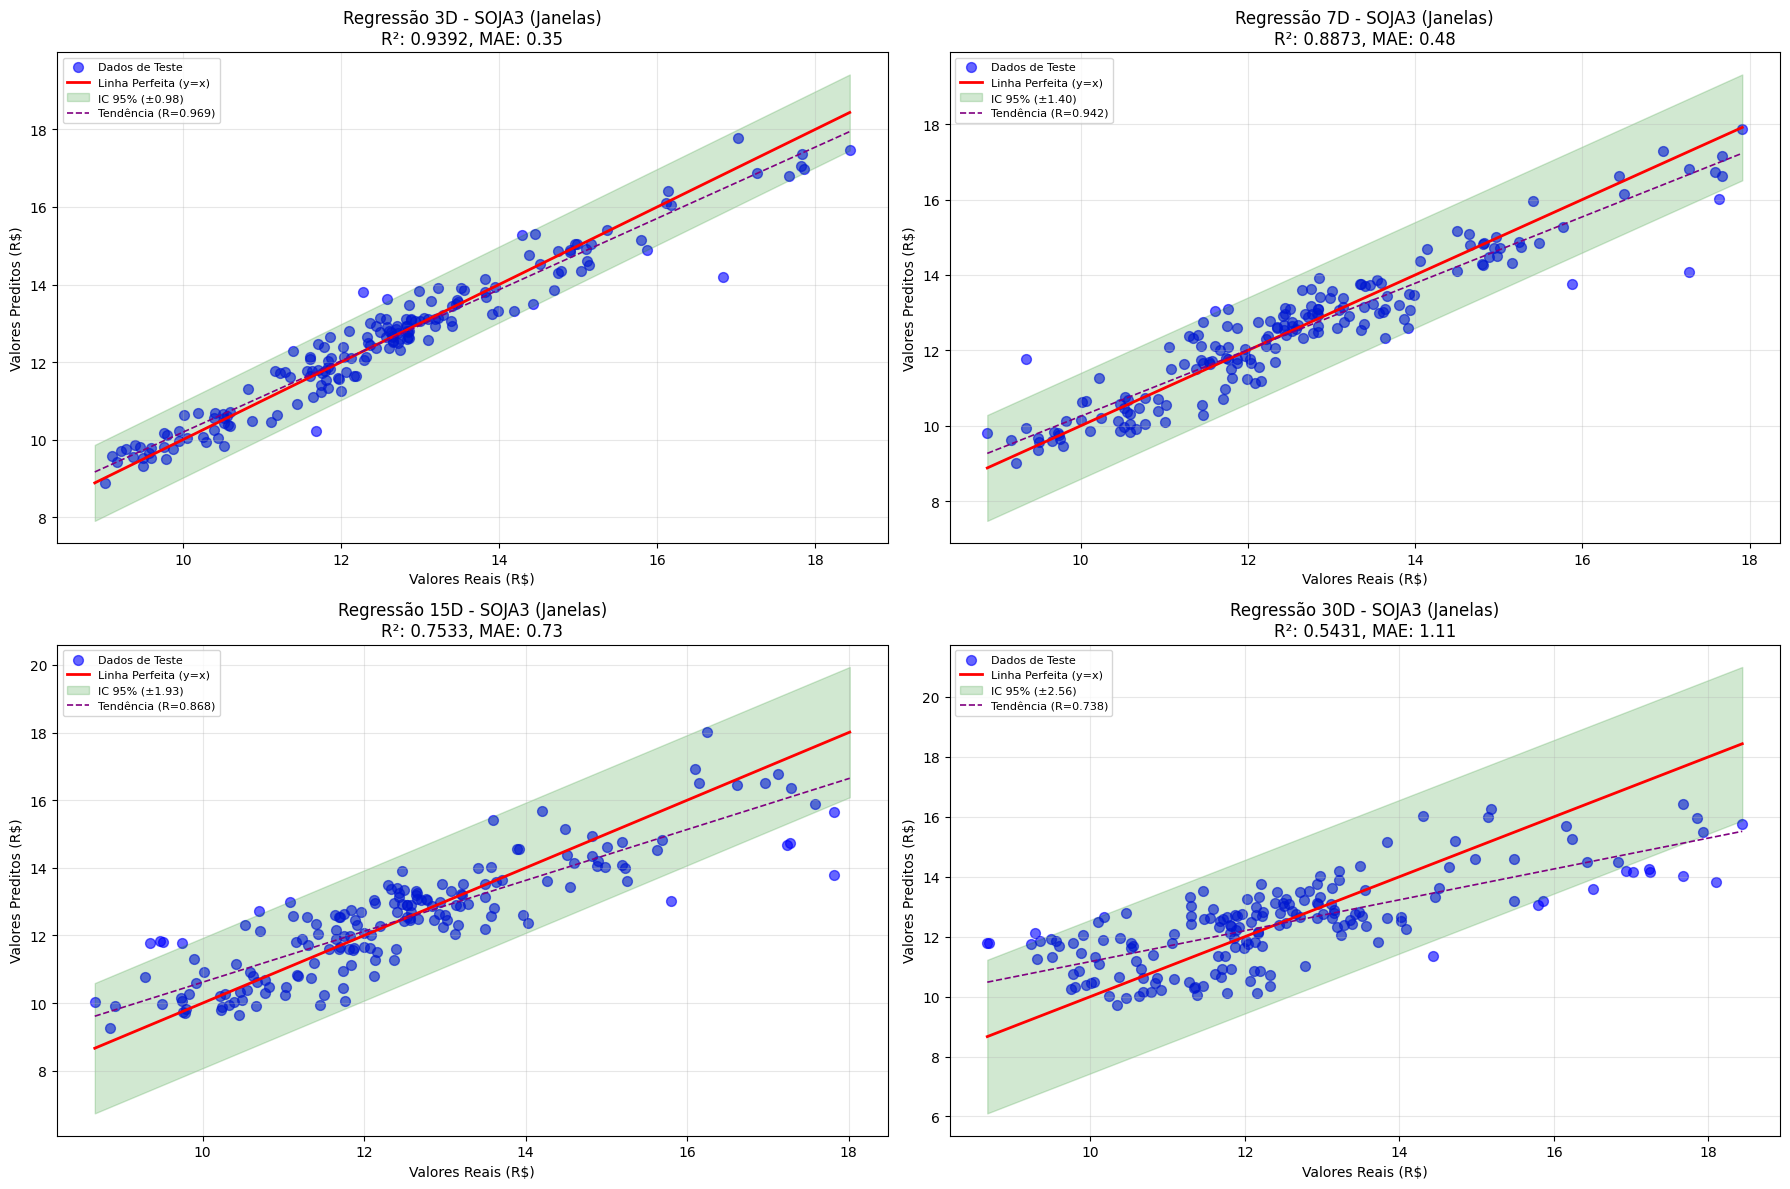

✓ Gráfico de dispersão com IC 95% salvo


In [11]:
# Gráficos de dispersão com linha de regressão e IC 95%
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']
    y_train = model_data['y_train']
    y_pred_train = model_data['model'].predict(model_data['X_train'])
    
    # Calcular MSE e desvio padrão dos resíduos
    mse = mean_squared_error(y_train, y_pred_train)
    residual_std = np.sqrt(mse)

    ax = axes[idx]

    # Scatter dos dados de teste
    ax.scatter(y_test, y_pred, alpha=0.6, color='blue', s=50, label='Dados de Teste')

    # Linha y = x
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    line_vals = np.linspace(min_val, max_val, 100)
    ax.plot(line_vals, line_vals, 'r-', linewidth=2, label='Linha Perfeita (y=x)')

    # Intervalo de confiança 95%
    confidence_interval = 1.96 * residual_std
    ax.fill_between(line_vals,
                    line_vals - confidence_interval,
                    line_vals + confidence_interval,
                    alpha=0.18, color='green',
                    label=f'IC 95% (±{confidence_interval:.2f})')

    # Linha de tendência
    slope, intercept, r_value, p_value, std_err = stats.linregress(y_test, y_pred)
    regression_line = slope * line_vals + intercept
    ax.plot(line_vals, regression_line, '--', color='purple', linewidth=1.2, label=f'Tendência (R={r_value:.3f})')

    ax.set_title(f'Regressão {period.upper()} - SOJA3 (Janelas)\nR²: {model_data["r2"]:.4f}, MAE: {model_data["mae"]:.2f}')
    ax.set_xlabel('Valores Reais (R$)')
    ax.set_ylabel('Valores Preditos (R$)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}dispersao_ic_soja3_janelas.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráfico de dispersão com IC 95% salvo")

### Evolução do R² e MAE por Horizonte

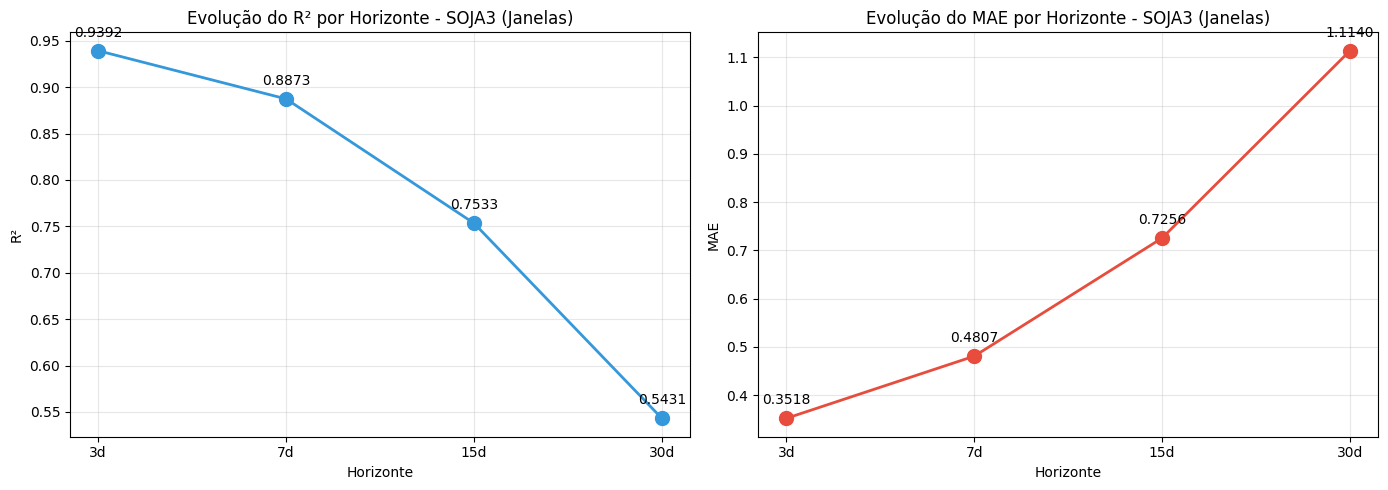

✓ Gráficos de evolução de R² e MAE salvos


In [12]:
# Evolução das métricas R² e MAE por horizonte
periods = ['3d', '7d', '15d', '30d']
r2_values = [models[p]['r2'] for p in periods]
mae_values = [models[p]['mae'] for p in periods]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot R²
axes[0].plot(periods, r2_values, marker='o', linewidth=2, markersize=10, color='#3498db')
axes[0].set_title('Evolução do R² por Horizonte - SOJA3 (Janelas)')
axes[0].set_xlabel('Horizonte')
axes[0].set_ylabel('R²')
axes[0].grid(True, alpha=0.3)
for i, v in enumerate(r2_values):
    axes[0].annotate(f'{v:.4f}', (periods[i], v), textcoords="offset points", xytext=(0,10), ha='center')

# Plot MAE
axes[1].plot(periods, mae_values, marker='o', linewidth=2, markersize=10, color='#e74c3c')
axes[1].set_title('Evolução do MAE por Horizonte - SOJA3 (Janelas)')
axes[1].set_xlabel('Horizonte')
axes[1].set_ylabel('MAE')
axes[1].grid(True, alpha=0.3)
for i, v in enumerate(mae_values):
    axes[1].annotate(f'{v:.4f}', (periods[i], v), textcoords="offset points", xytext=(0,10), ha='center')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}evolucao_metricas_soja3_janelas.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Gráficos de evolução de R² e MAE salvos')

### Resumo Final

In [13]:
print("\n" + "="*60)
print("RESUMO FINAL - REGRESSÃO LINEAR SOJA3 (DATASET JANELAS)")
print("="*60)
print("\n✓ 4 modelos treinados (horizontes: 3d, 7d, 15d, 30d)")
print(f"✓ Features base: {base_features}")
print(f"✓ Features de lag: {lag_cols}")
print(f"✓ Total de features: {len(base_features + lag_cols)}")
print("\nMétricas por horizonte:")
for period in ['3d', '7d', '15d', '30d']:
    print(f"  {period}: R²={models[period]['r2']:.4f}, MAE={models[period]['mae']:.4f}, RMSE={models[period]['rmse']:.4f}")

print("\nArquivos gerados:")
print("  - metricas_soja3_janelas.csv")
print("  - serie_temporal_soja3_janelas.png")
print("  - residuos_soja3_janelas.png")
print("  - real_vs_predito_soja3_janelas.png")
print("  - comparacao_metricas_soja3_janelas.png")
print("  - histograma_residuos_soja3_janelas.png")
print("  - residuos_temporais_soja3_janelas.png")
print("  - dispersao_ic_soja3_janelas.png")
print("  - evolucao_metricas_soja3_janelas.png")
print("="*60)


RESUMO FINAL - REGRESSÃO LINEAR SOJA3 (DATASET JANELAS)

✓ 4 modelos treinados (horizontes: 3d, 7d, 15d, 30d)
✓ Features base: ['Close', 'Low', 'High', 'Open']
✓ Features de lag: ['Open_lag2d', 'Open_lag4d', 'Open_lag6d', 'High_lag2d', 'High_lag4d', 'High_lag6d', 'Low_lag2d', 'Low_lag4d', 'Low_lag6d', 'Close_lag2d', 'Close_lag4d', 'Close_lag6d']
✓ Total de features: 16

Métricas por horizonte:
  3d: R²=0.9392, MAE=0.3518, RMSE=0.4870
  7d: R²=0.8873, MAE=0.4807, RMSE=0.6502
  15d: R²=0.7533, MAE=0.7256, RMSE=0.9695
  30d: R²=0.5431, MAE=1.1140, RMSE=1.3997

Arquivos gerados:
  - metricas_soja3_janelas.csv
  - serie_temporal_soja3_janelas.png
  - residuos_soja3_janelas.png
  - real_vs_predito_soja3_janelas.png
  - comparacao_metricas_soja3_janelas.png
  - histograma_residuos_soja3_janelas.png
  - residuos_temporais_soja3_janelas.png
  - dispersao_ic_soja3_janelas.png
  - evolucao_metricas_soja3_janelas.png
